<a href="https://colab.research.google.com/github/Anikgarg05/IntrusionDetectionSystem/blob/main/intrusionDetectionSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
from google.colab import files
file = files.upload()
df = pd.read_csv(next(iter(file.keys())))

Saving kdd_test.csv to kdd_test.csv


In [ ]:
print("Shape:", df.shape)
print(df.head())

Shape: (22544, 42)
   duration protocol_type   service  flag  src_bytes  dst_bytes  land  \
0         5           tcp      smtp    SF       2429        475     0   
1         0           udp  domain_u    SF         45        134     0   
2         0           udp  domain_u    SF         45         80     0   
3      1979           udp     other    SF        145        105     0   
4     14462           tcp     other  RSTR          1          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  57   
1               0       0    0  ...                 155   
2               0       0    0  ...                 255   
3               0       0    0  ...                   2   
4               0       0    0  ...                   2   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.11                    0.02   
1                    0.80                    0.02   
2                    1.00   

In [ ]:
df.isnull().sum()
df=df.dropna()

In [ ]:
X=df.drop(['land','urgent','num_failed_logins','su_attempted','num_outbound_cmds','is_host_login','labels'],axis=1)
Y=df['labels']

In [ ]:
df.shape

(22544, 42)

In [ ]:
def attack_category(label):

    dos = ['neptune','smurf','back','teardrop','apache2','mailbomb','processtable','udpstorm','land']

    probe = ['satan','ipsweep','portsweep','nmap','mscan','saint']

    r2l = ['guess_passwd','warezclient','warezmaster','imap','phf',
           'multihop','ftp_write','spy','snmpguess','snmpgetattack',
           'httptunnel','named']

    u2r = ['buffer_overflow','loadmodule','perl','rootkit','xterm','ps','sqlattack']

    if label == 'normal':
        return 'Normal'
    elif label in dos:
        return 'DoS'
    elif label in probe:
        return 'Probe'
    elif label in r2l:
        return 'R2L'
    elif label in u2r:
        return 'U2R'
    else:
        return 'Other'


In [ ]:
df['labels'].value_counts()

,count
labels,
normal,11245
neptune,6654
satan,698
smurf,540
ipsweep,479
guess_passwd,411
portsweep,371
mscan,310
warezmaster,279


In [ ]:
df['attack_class'] = df['labels'].apply(attack_category)

In [ ]:
df['attack_class'].value_counts()

,count
attack_class,
Normal,11245
DoS,8060
Probe,2157
R2L,996
Other,48
U2R,38


In [ ]:
counts = df['attack_class'].value_counts()

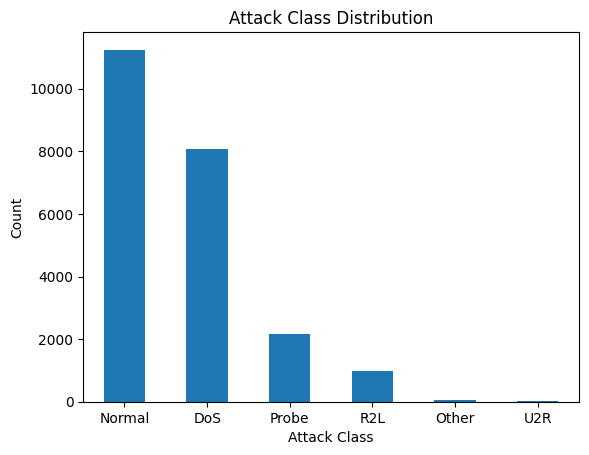

In [ ]:
plt.figure()
counts.plot(kind='bar')

plt.title('Attack Class Distribution')
plt.xlabel('Attack Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

In [ ]:
X = df.drop(['labels','attack_class'], axis=1)
Y = df['attack_class']

In [ ]:
encoder = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = encoder.fit_transform(X[col])

In [ ]:
Y = encoder.fit_transform(Y)

In [ ]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [ ]:
X

array([[9.18256781e-05, 5.00000000e-01, 7.84615385e-01, ...,
        0.00000000e+00, 8.70000000e-01, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 1.84615385e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 1.84615385e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 5.00000000e-01, 7.07692308e-01, ...,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 5.00000000e-01, 7.07692308e-01, ...,
        0.00000000e+00, 5.80000000e-01, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 1.84615385e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
Y

array([1, 1, 1, ..., 0, 3, 1])

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
models = {

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(n_estimators=100),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

In [ ]:
results = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)
    results[name] = acc
    print("Accuracy:",acc)
    print(classification_report(Y_test, Y_pred))

Accuracy: 0.9844754934575294
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1644
           1       0.99      0.99      0.99      2239
           2       1.00      0.67      0.80         9
           3       0.97      0.97      0.97       402
           4       0.95      0.94      0.94       204
           5       0.42      0.45      0.43        11

    accuracy                           0.98      4509
   macro avg       0.89      0.84      0.85      4509
weighted avg       0.98      0.98      0.98      4509

Accuracy: 0.9875803947660236
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1644
           1       0.98      0.99      0.99      2239
           2       1.00      0.67      0.80         9
           3       0.97      0.99      0.98       402
           4       0.97      0.91      0.94       204
           5       0.75      0.27      0.40        11

    accuracy       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.9764914615214016
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1644
           1       0.98      0.98      0.98      2239
           2       1.00      0.44      0.62         9
           3       0.95      0.95      0.95       402
           4       0.88      0.90      0.89       204
           5       0.75      0.27      0.40        11

    accuracy                           0.98      4509
   macro avg       0.93      0.76      0.81      4509
weighted avg       0.98      0.98      0.98      4509

Accuracy: 0.34420048791306274
              precision    recall  f1-score   support

           0       0.77      0.68      0.73      1644
           1       0.33      0.01      0.01      2239
           2       0.00      0.78      0.01         9
           3       0.25      0.78      0.38       402
           4       0.58      0.40      0.47       204
           5       0.24      0.73      0.36        11

    accuracy      

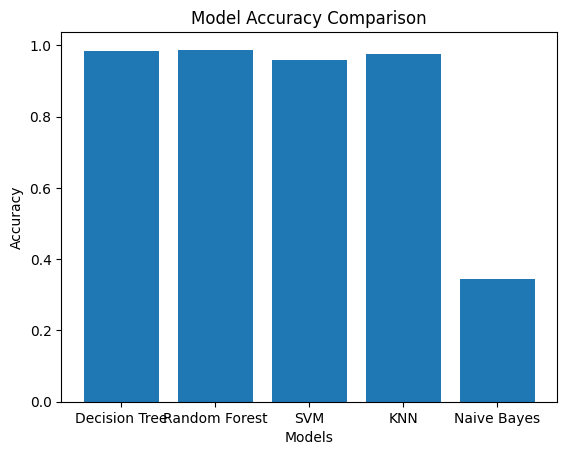

In [ ]:
plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

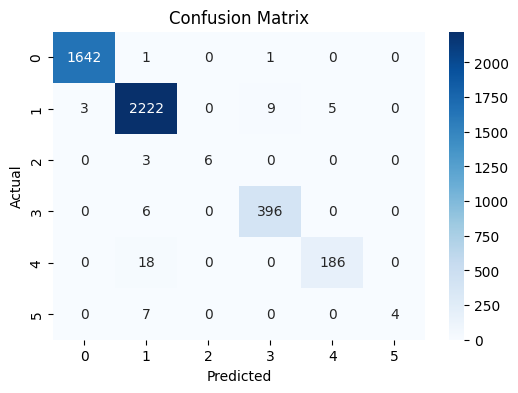

In [ ]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

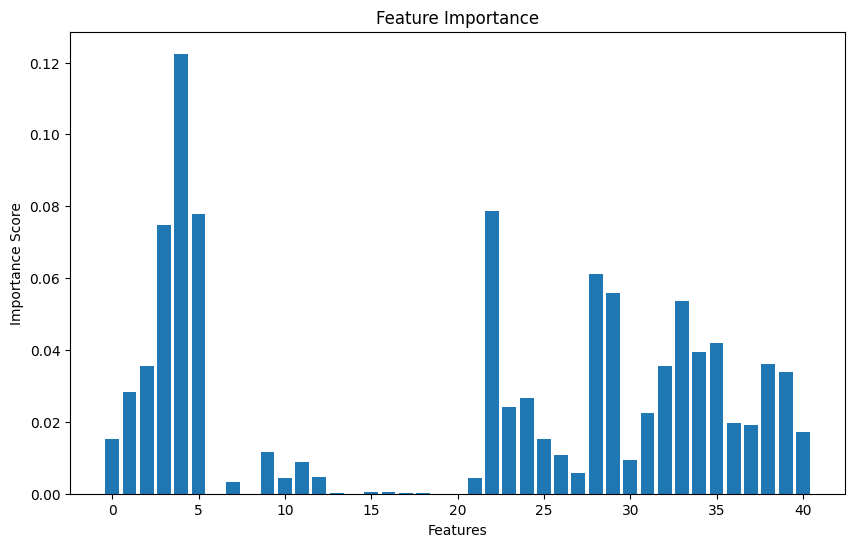

In [ ]:
importances = model.feature_importances_

plt.figure(figsize=(10,6))

plt.bar(range(len(importances)), importances)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()